In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from methods import *
from loss import *

colors = sns.color_palette("colorblind")
colors = sns.color_palette("bright")
markers = ['o', '^', 'v', '<', '>', 's', 'D', 'd', 'p', 'h', 'H', '8', 'X', '*', '.', 'P', 'x', '+', '1', '2', '3', '4', '|', '_']
colors = sns.color_palette("bright", n_colors=len(markers))

seed = 3107

/home/dimoik/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Problem

In [2]:
np.random.seed(seed)

n = 300
d = 100
cons = False
loss = PhaseRetrieval(n, d, cons)

x0 = np.random.randn(loss.d)
f0 = loss.func(x0, np.arange(loss.n))

if cons:
    f_star = 0
    x_star = loss.x_star
else:
    K = 50000
    name, f, x = GD(loss, K, x0, gamma=0.01, return_x=True)
    f_star = f[-1]
    x_star = x[-1]

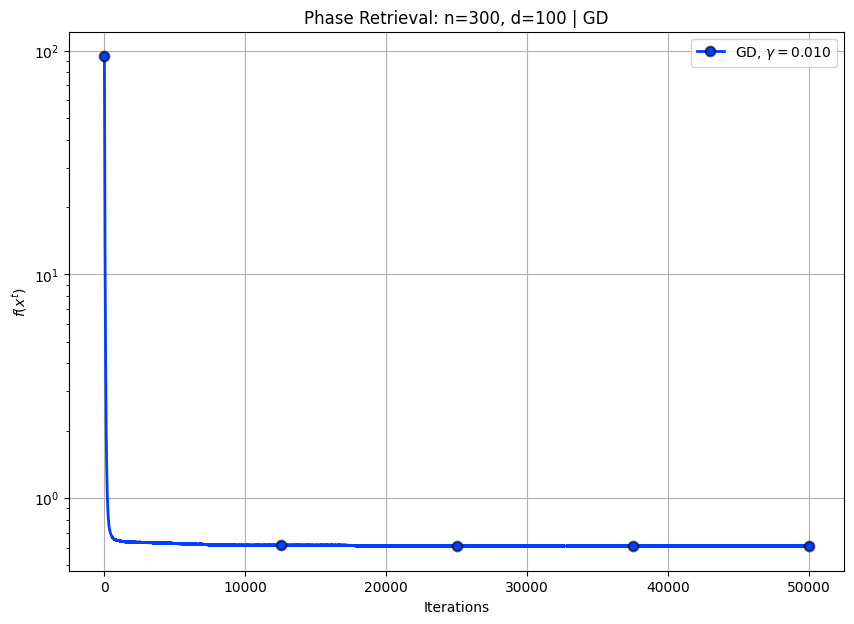

In [3]:
# Plotting
fig, ax = plt.subplots(figsize=(10,7))
scale = 1
fs = 10

j = 0
# plt.plot(np.arange(f.shape[0]), (f-f_star)/(f0-f_star), color = colors[j], linewidth=2, label=name, markevery=np.linspace(0, K-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])
# plt.ylabel(r'$\frac{f(x^t)-f(x^*)}{f(x^0)-f(x^*)}$', fontsize=fs)

plt.plot(np.arange(f.shape[0]), f, color = colors[j], linewidth=2, label=name, markevery=np.linspace(0, K-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])
plt.ylabel(r'$f(x^t)$', fontsize=fs)

plt.yscale("log")
plt.xscale("linear")
plt.xlabel('Iterations', fontsize=fs)
plt.legend(fontsize=fs)
plt.grid(True)

type_name = 'GD'
title_name = loss.name+': n='+str(n)+', d='+str(d)+' | '+type_name
save_name = loss.save_name+'_n='+str(n)+'_d='+str(d)+'_'+type_name
plt.title(title_name)


plt.show()
# plt.savefig('figures/'+save_name+'.pdf', bbox_inches='tight')

## Sensitivity analysis of M

### SGD

In [ ]:
np.random.seed(seed)
eps = 1e-5

trials = 2
epochs = 100
bs = n//2
bs = 30

K = epochs * n
record_f = np.arange(0, K+1, n)

name_list = []
f_list = []
ss_list = []
norms_list = []
tru_list = []


M_list = [1.0, 10.0, 100.0]
for M in M_list:
    name, f, ss, norms, tru = sgd_sps_m(loss, trials, record_f, x0, M, eps, bs)
    name_list.append(name);f_list.append(f);ss_list.append(ss);norms_list.append(norms);tru_list.append(tru)

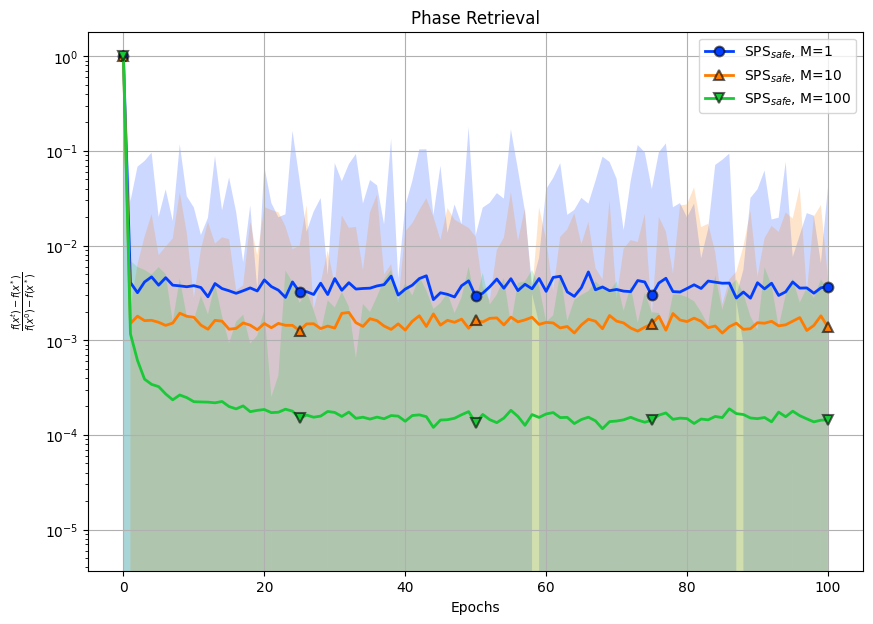

In [17]:
# Plotting
fig, ax = plt.subplots(figsize=(10,7))
scale = 1
fs = 10

j = 0
mean_f = np.mean((f_list[j]-f_star)/(f0-f_star), axis=1)
# mean_f = np.mean(f_list[j], axis=1)
std_f = np.std(f_list[j], axis=1)
plt.fill_between(np.arange(mean_f.shape[0]), mean_f-scale*std_f, mean_f+scale*std_f, alpha=0.2, fc=colors[j])
plt.plot(np.arange(mean_f.shape[0]), mean_f, color = colors[j], linewidth=2, label=r'SPS$_{safe}$, M=1', markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])

j += 1
mean_f = np.mean((f_list[j]-f_star)/(f0-f_star), axis=1)
# mean_f = np.mean(f_list[j], axis=1)
std_f = np.std(f_list[j], axis=1)
plt.fill_between(np.arange(mean_f.shape[0]), mean_f-scale*std_f, mean_f+scale*std_f, alpha=0.2, fc=colors[j])
plt.plot(np.arange(mean_f.shape[0]), mean_f, color = colors[j], linewidth=2, label=r'SPS$_{safe}$, M=10', markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])


j += 1
mean_f = np.mean((f_list[j]-f_star)/(f0-f_star), axis=1)
# mean_f = np.mean(f_list[j], axis=1)
std_f = np.std(f_list[j], axis=1)
plt.fill_between(np.arange(mean_f.shape[0]), mean_f-scale*std_f, mean_f+scale*std_f, alpha=0.2, fc=colors[j])
plt.plot(np.arange(mean_f.shape[0]), mean_f, color = colors[j], linewidth=2, label=r'SPS$_{safe}$, M=100', markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])



plt.yscale("log")
plt.xscale("linear")
plt.xlabel('Epochs', fontsize=fs)
plt.ylabel(r'$\frac{f(x^t)-f(x^*)}{f(x^0)-f(x^*)}$', fontsize=fs)
# plt.ylabel(r'$f(x^t)$', fontsize=fs)
plt.legend(fontsize=fs)
plt.grid(True)

title_name = loss.name+': n='+str(n)+', d='+str(d)+' | '+type_name
save_name = loss.save_name+'_n='+str(n)+'_d='+str(d)+'_'+type_name
plt.title('Phase Retrieval')


# plt.show()
# plt.savefig('figures/'+save_name+'.pdf', bbox_inches='tight')
plt.savefig('figures/pr_sgd_sens.pdf', bbox_inches='tight')

### IMA

In [ ]:
np.random.seed(seed)
eps = 1e-5

trials = 2
epochs = 100
bs = n//2
bs = 30

K = epochs * n
record_f = np.arange(0, K+1, n)

name_list = []
f_list = []
ss_list = []
norms_list = []
tru_list = []



M_list = [1.0, 10.0, 100.0]
lambd = 9.0
for M in M_list:
    name, f, ss, norms, tru = ima_sps_m(loss, trials, record_f, x0, lambd, M, eps, bs)
    name_list.append(name);f_list.append(f);ss_list.append(ss);norms_list.append(norms);tru_list.append(tru)


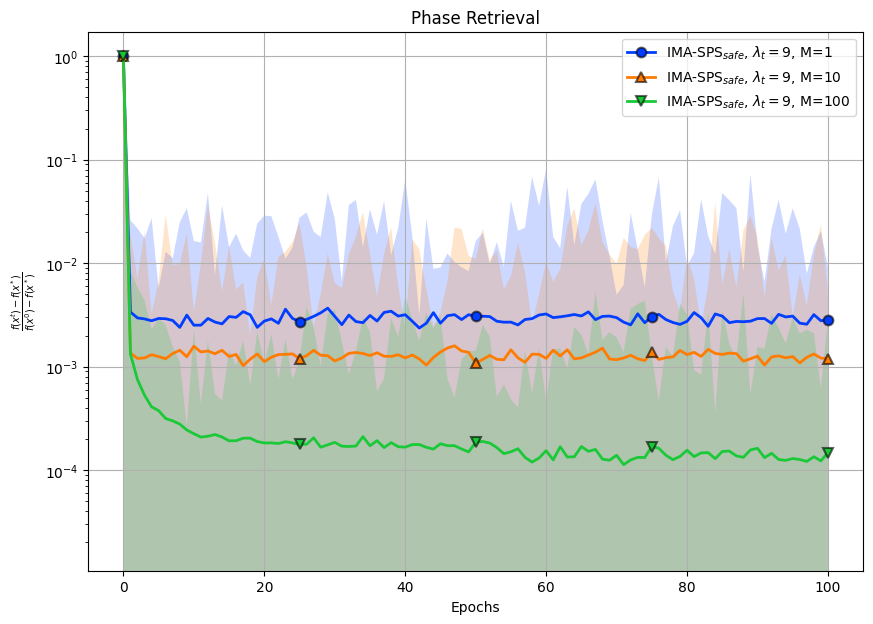

In [9]:
# Plotting
fig, ax = plt.subplots(figsize=(10,7))
scale = 1
fs = 10

j = 0
mean_f = np.mean((f_list[j]-f_star)/(f0-f_star), axis=1)
# mean_f = np.mean(f_list[j], axis=1)
std_f = np.std(f_list[j], axis=1)
plt.fill_between(np.arange(mean_f.shape[0]), mean_f-scale*std_f, mean_f+scale*std_f, alpha=0.2, fc=colors[j])
plt.plot(np.arange(mean_f.shape[0]), mean_f, color = colors[j], linewidth=2, label=r'IMA-SPS$_{safe}$, $\lambda_t=9$, M=1', markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])

j += 1
mean_f = np.mean((f_list[j]-f_star)/(f0-f_star), axis=1)
# mean_f = np.mean(f_list[j], axis=1)
std_f = np.std(f_list[j], axis=1)
plt.fill_between(np.arange(mean_f.shape[0]), mean_f-scale*std_f, mean_f+scale*std_f, alpha=0.2, fc=colors[j])
plt.plot(np.arange(mean_f.shape[0]), mean_f, color = colors[j], linewidth=2, label=r'IMA-SPS$_{safe}$, $\lambda_t=9$, M=10', markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])


j += 1
mean_f = np.mean((f_list[j]-f_star)/(f0-f_star), axis=1)
# mean_f = np.mean(f_list[j], axis=1)
std_f = np.std(f_list[j], axis=1)
plt.fill_between(np.arange(mean_f.shape[0]), mean_f-scale*std_f, mean_f+scale*std_f, alpha=0.2, fc=colors[j])
plt.plot(np.arange(mean_f.shape[0]), mean_f, color = colors[j], linewidth=2, label=r'IMA-SPS$_{safe}$, $\lambda_t=9$, M=100', markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])



plt.yscale("log")
plt.xscale("linear")
plt.xlabel('Epochs', fontsize=fs)
plt.ylabel(r'$\frac{f(x^t)-f(x^*)}{f(x^0)-f(x^*)}$', fontsize=fs)
# plt.ylabel(r'$f(x^t)$', fontsize=fs)
plt.legend(fontsize=fs)
plt.grid(True)

title_name = loss.name+': n='+str(n)+', d='+str(d)+' | '+type_name
save_name = loss.save_name+'_n='+str(n)+'_d='+str(d)+'_'+type_name
plt.title('Phase Retrieval')


# plt.show()
# plt.savefig('figures/'+save_name+'.pdf', bbox_inches='tight')
plt.savefig('figures/pr_ima_sens.pdf', bbox_inches='tight')